In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent  # sube una carpeta: notebooks -> PyDSGEforge

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project_root:", ROOT)

project_root: C:\Users\alejo\OneDrive\Escritorio\Pablo\Profesional\Modelaje\Econometria\PyDSGEforge


In [4]:
import numpy as np
import pandas as pd
import sympy as sp
from pathlib import Path
from statsmodels.tsa.filters.hp_filter import hpfilter

from src.dsge import DSGE
from src.model_builders.steady import SteadyConfig
from src.specification.param_registry_class import ParamRegistry
from src.specification.param_specifications import ParamSpec, PriorSpec, QSpec, HSpec

In [5]:
x_t, pi_t, i_t = sp.symbols("x_t pi_t i_t")
x_tp1, pi_tp1 = sp.symbols("x_tp1 pi_tp1")
eps_d, eps_s, eps_m = sp.symbols("eps_d eps_s eps_m")

beta, sigma, kappa, phi_pi, phi_x = sp.symbols("beta sigma kappa phi_pi phi_x")
sig_d, sig_s, sig_m = sp.symbols("sig_d sig_s sig_m")

equations = [
    sp.Eq(x_t, x_tp1 - (1 / sigma) * (i_t - pi_tp1) + eps_d),
    sp.Eq(pi_t, beta * pi_tp1 + kappa * x_t + eps_s),
    sp.Eq(i_t, phi_pi * pi_t + phi_x * x_t + eps_m)]


In [6]:
model = DSGE(
    equations=equations,
    y_t=[x_t, pi_t, i_t],
    y_tp1=[x_tp1, pi_tp1],
    eps_t=[eps_d, eps_s, eps_m],
    metadata={"name": "NK_Colombia", "source": "nk_colombia.mod"})

model

<DSGE 3 eqs | 3 states (+2 leads, 0 lags) | 3 shocks | name=NK_Colombia, source=nk_colombia.mod>

In [7]:
def gamma_from_moments(mean, std):
    shape = (mean / std) ** 2
    scale = std**2 / mean
    return shape, scale

G_sigma = gamma_from_moments(1.50, 0.50)
G_kappa = gamma_from_moments(0.10, 0.05)
G_phi_pi = gamma_from_moments(1.50, 0.30)
G_phi_x = gamma_from_moments(0.50, 0.20)

In [8]:
REG_NK_CO = ParamRegistry(
    params=[
        ParamSpec(
            "beta",
            beta,
            transform="logistic",  # fuerza 0<beta<1
            prior=PriorSpec("normal", {"loc": 0.99, "scale": 0.005}),
            role="struct",
        ),
        ParamSpec(
            "sigma",
            sigma,
            transform="exp",
            prior=PriorSpec("gamma", {"a": G_sigma[0], "scale": G_sigma[1]}),
            role="struct",
        ),
        ParamSpec(
            "kappa",
            kappa,
            transform="exp",
            prior=PriorSpec("gamma", {"a": G_kappa[0], "scale": G_kappa[1]}),
            role="struct",
        ),
        ParamSpec(
            "phi_pi",
            phi_pi,
            transform="exp",
            prior=PriorSpec("gamma", {"a": G_phi_pi[0], "scale": G_phi_pi[1]}),
            role="struct",
        ),
        ParamSpec(
            "phi_x",
            phi_x,
            transform="exp",
            prior=PriorSpec("gamma", {"a": G_phi_x[0], "scale": G_phi_x[1]}),
            role="struct",
        ),
        ParamSpec(
            "sig_d",
            sig_d,
            transform="exp",
            prior=PriorSpec("invgamma", {"a": 6.0, "scale": 1.0}),  # media≈0.2, sd≈0.1
            role="shock_std",
        ),
        ParamSpec(
            "sig_s",
            sig_s,
            transform="exp",
            prior=PriorSpec("invgamma", {"a": 6.0, "scale": 1.0}),
            role="shock_std",
        ),
        ParamSpec(
            "sig_m",
            sig_m,
            transform="exp",
            prior=PriorSpec("invgamma", {"a": 6.0, "scale": 1.0}),
            role="shock_std",
        ),
    ],
    qspec=QSpec(diag_params=["sig_d", "sig_s", "sig_m"]),
    hspec=HSpec(fixed=np.zeros((3, 3))),
)


(<Figure size 1000x600 with 9 Axes>,
 array([[<Axes: title={'center': 'beta (normal)'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'sigma (gamma)'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'kappa (gamma)'}, xlabel='Valor económico', ylabel='densidad'>],
        [<Axes: title={'center': 'phi_pi (gamma)'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'phi_x (gamma)'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'sig_d (invgamma)'}, xlabel='Valor económico', ylabel='densidad'>],
        [<Axes: title={'center': 'sig_s (invgamma)'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'sig_m (invgamma)'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: >]], dtype=object))

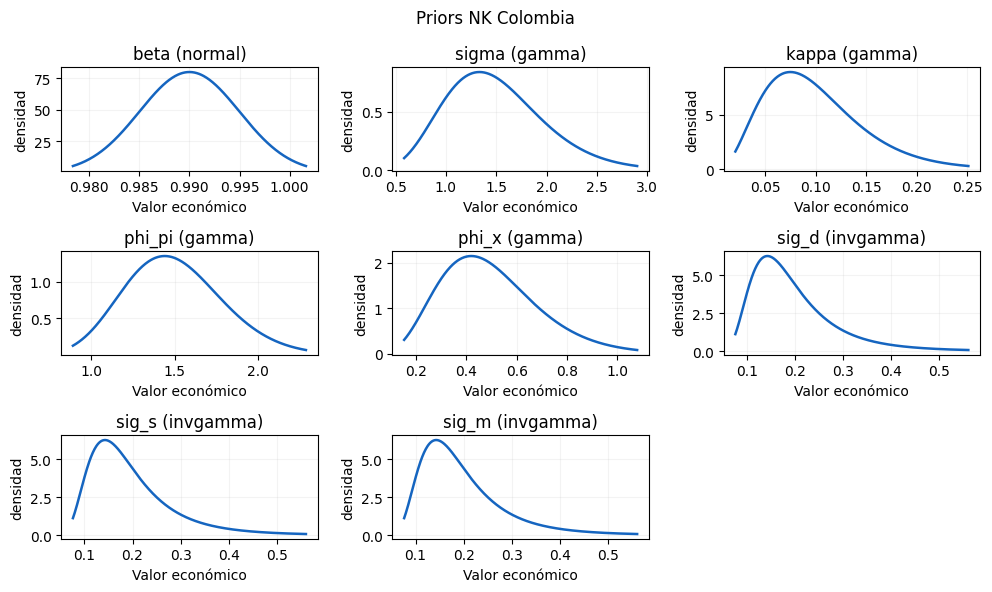

In [9]:
model.prior(
    registry=REG_NK_CO,
    title="Priors NK Colombia",
    quantile_bounds=(0.01, 0.99),
)

In [10]:
theta_init = {
    "beta": 0.99,
    "sigma": 1.50,
    "kappa": 0.10,
    "phi_pi": 1.50,
    "phi_x": 0.50,
    "sig_d": 0.20,
    "sig_s": 0.20,
    "sig_m": 0.20,
}

In [15]:
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter

inflacion = pd.read_excel(r'C:\Users\alejo\OneDrive\Escritorio\Pablo\Profesional\Modelaje\Econometria\PyDSGEforge\data\Inflacion.xlsx')
pib = pd.read_excel(r'C:\Users\alejo\OneDrive\Escritorio\Pablo\Profesional\Modelaje\Econometria\PyDSGEforge\data\pib.xlsx')
tpm = pd.read_excel(r'C:\Users\alejo\OneDrive\Escritorio\Pablo\Profesional\Modelaje\Econometria\PyDSGEforge\data\tpm.xlsx')

inflacion.columns = ["Fecha", "Inflacion"]
pib.columns       = ["Fecha", "PIB"]
tpm.columns       = ["Fecha", "TPM"]

inflacion["Fecha"] = pd.to_datetime(inflacion["Fecha"])
pib["Fecha"]  = pd.to_datetime(pib["Fecha"])
tpm["Fecha"] = pd.to_datetime(tpm["Fecha"])

inflacion = inflacion.set_index("Fecha").sort_index()
pib       = pib.set_index("Fecha").sort_index()
tpm       = tpm.set_index("Fecha").sort_index()

tpm_q = tpm.resample("QE").mean() 

inf_series = inflacion["Inflacion"].dropna()
def inflation_quarterly_annualized_from_series(s: pd.Series) -> pd.Series:
    """
    Si 's' es un índice de precios (grande, p.ej. >50): π_q = 400*Δlog(IPC_Q).
    Si 's' está en % anual (y/y): des-anualiza a trimestral y anualiza: π_q = 400*((1+π_yoy)^(1/4)-1).
    Ambas devuelven serie trimestral en puntos anuales (p.p.).
    """
    if s.max() > 50:  # parece índice de nivel
        idx_q = s.resample("QE").last()
        pi_q = 400 * np.log(idx_q / idx_q.shift(1))
        return pi_q
    else: 
        yoy_q = (s.resample("QE").mean()) / 100.0 
        qoq = (1.0 + yoy_q)**(1/4) - 1.0         
        pi_q = 400 * qoq                          
        return pi_q

pi_q = inflation_quarterly_annualized_from_series(inf_series)
pi_q = pi_q.to_frame("pi")

pib_q = pib.resample("QE").last() if pib.index.freq is None else pib.copy()

log_y = np.log(pib_q["PIB"])
cycle, trend = hpfilter(log_y, lamb=1600)
x_gap = 100.0 * cycle
x_gap = x_gap.to_frame("x")

df = x_gap.join(pi_q, how="inner").join(tpm_q.rename(columns={"TPM": "i"}), how="inner")

df = df.dropna().copy()


df = df[["x", "pi", "i"]]
Y = df.to_numpy(dtype=float)

print(df.head())
print("Shape:", Y.shape)

                   x        pi         i
Fecha                                   
2005-03-31 -1.309490  5.136864  6.500000
2005-06-30 -0.717852  4.870326  6.500000
2005-09-30 -1.835583  4.847822  6.434783
2005-12-31 -1.361902  4.979574  6.000000
2006-03-31 -0.329264  4.219432  6.000000
Shape: (82, 3)


c:\ProgramData\miniconda3\envs\deep_learning\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


In [16]:
LOGIT = lambda p: np.log(p / (1.0 - p))
MAP_BOUNDS = [
    (LOGIT(0.90), LOGIT(0.999)),  # beta
    (np.log(0.2), np.log(5.0)),   # sigma
    (np.log(0.01), np.log(0.5)),  # kappa
    (np.log(1.0), np.log(4.0)),   # phi_pi
    (np.log(0.05), np.log(1.0)),  # phi_x
    (np.log(0.05), np.log(1.0)),  # sig_d
    (np.log(0.05), np.log(1.0)),  # sig_s
    (np.log(0.05), np.log(1.0)),  # sig_m
]


c:\ProgramData\miniconda3\envs\deep_learning\Lib\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


MAP success: True `xtol` termination condition is satisfied.
MAP optimization Complete: Starting Metropolis Hastings

[adapt] it=1000 rate=0.340 scale=2.000e+00
[adapt] it=2000 rate=0.324 scale=2.000e+00
[adapt] it=3000 rate=0.356 scale=4.000e+00
[Inference] it=4000 rate=0.184 scale=4.000e+00
[Inference] it=5000 rate=0.170 scale=4.000e+00
[Metropolis] acceptance rate: 0.281 (1403/5000) scale=4.000e+00


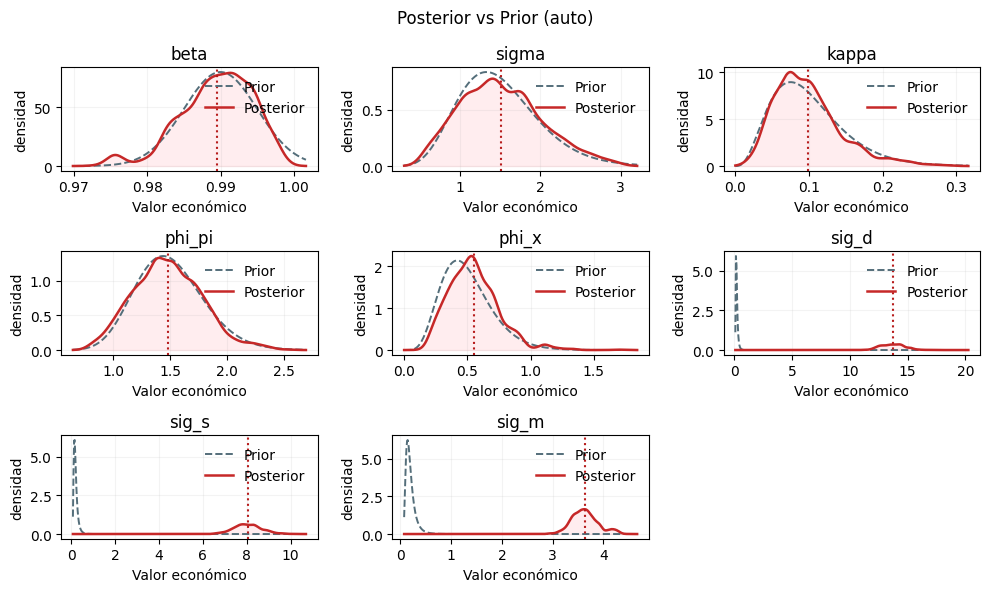

In [17]:
results = model.compute(
    registry=REG_NK_CO,
    theta_struct=theta_init,
    data=Y,
    include_jacobian_prior=True,       
    map=True,
    map_bounds="auto",
    map_kwargs={
        "method": "trust-constr",
        "hess_step": 1e-4,
        "tau_scale": 0.3},
    run_mcmc=True,
    mcmc_draws=5000,
    mcmc_kwargs={
        "include_jacobian_prior": True, 
        "adapt": True,
        "warmup": 3000,
        "adapt_block": 500,
        "logs": True,
        "log_every": 1000
    })


(<Figure size 1000x600 with 9 Axes>,
 array([[<Axes: title={'center': 'beta'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'sigma'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'kappa'}, xlabel='Valor económico', ylabel='densidad'>],
        [<Axes: title={'center': 'phi_pi'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'phi_x'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'sig_d'}, xlabel='Valor económico', ylabel='densidad'>],
        [<Axes: title={'center': 'sig_s'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: title={'center': 'sig_m'}, xlabel='Valor económico', ylabel='densidad'>,
         <Axes: >]], dtype=object))

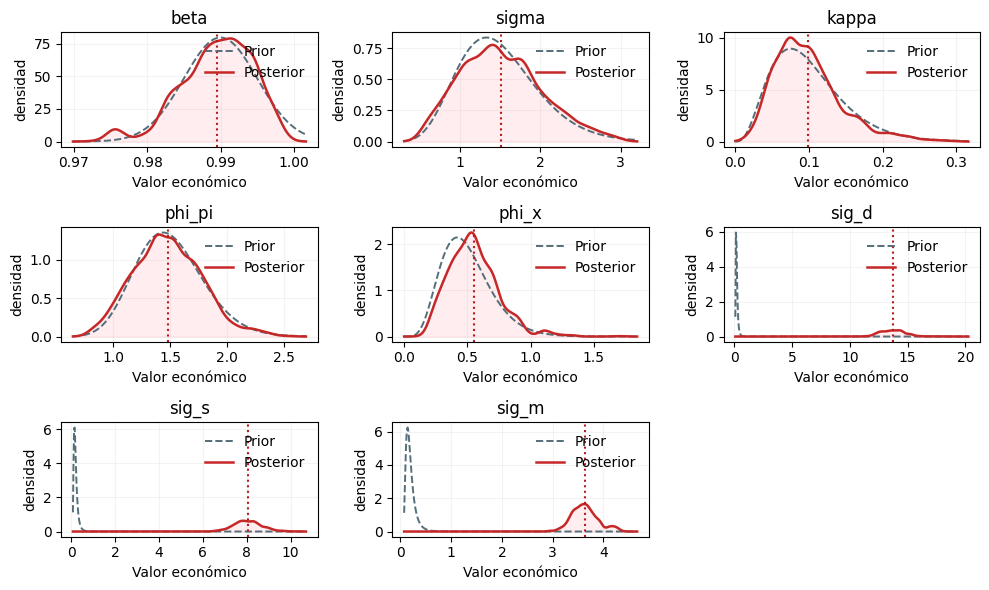

In [18]:
model.posterior()

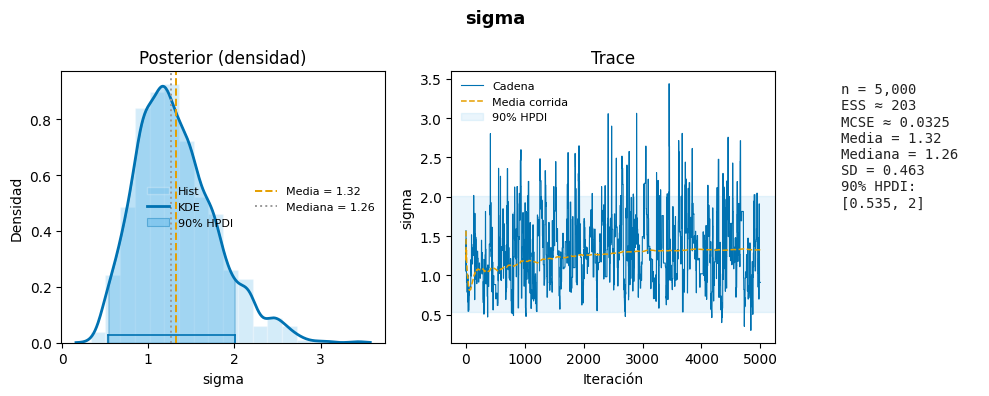

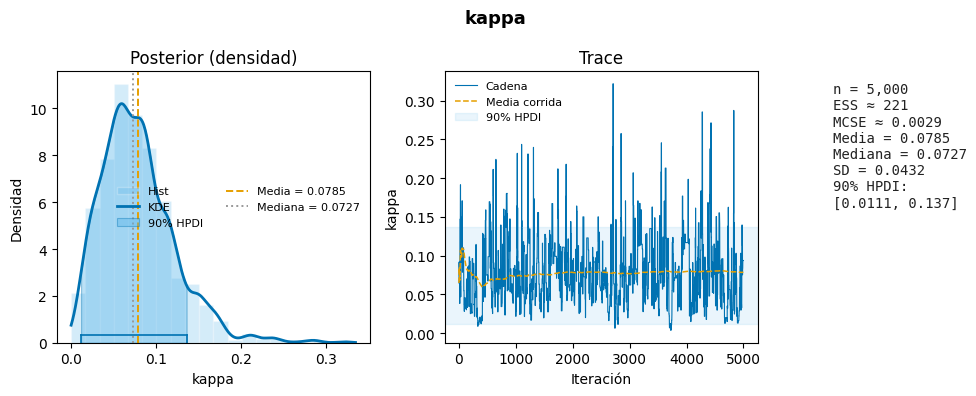

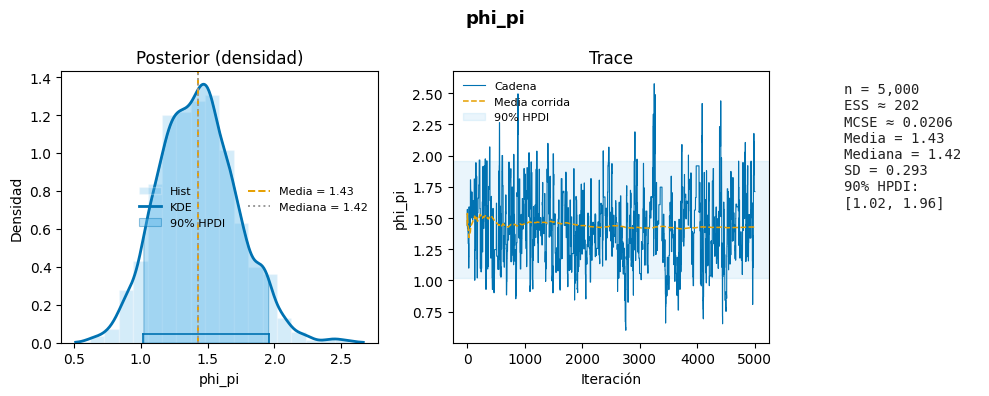


Posterior (espacio económico) | draws usados: 5000/10000 (burn-in=5000) | tasa de aceptación: 0.267
          mean      std     25%     50%    75%
beta    0.9953 0.005268  0.9915  0.9979 0.9999
sigma    1.323   0.4628  0.9804   1.259  1.595
kappa  0.07851   0.0432 0.04798 0.07268 0.1009
phi_pi    1.43   0.2927   1.221   1.425  1.618
phi_x   0.4073   0.1788  0.2788  0.3737 0.5007
sig_d    13.45    0.984   12.75   13.41  14.09
sig_s    7.952   0.5893   7.521    7.93   8.34
sig_m     3.57   0.2764   3.374    3.54  3.753


In [12]:
model.analyze_posteriors(subset=['sigma' , 'kappa' , 'phi_pi'])

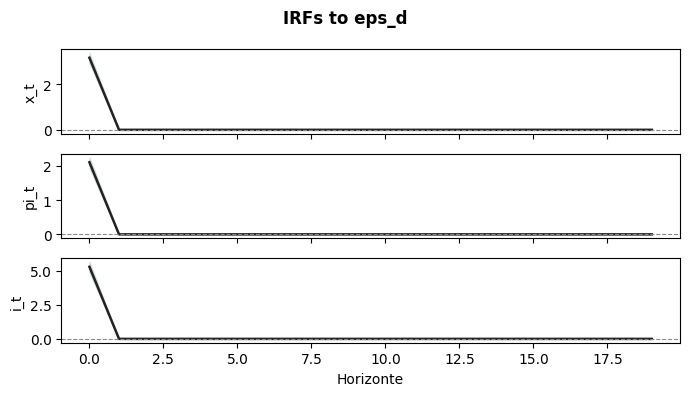

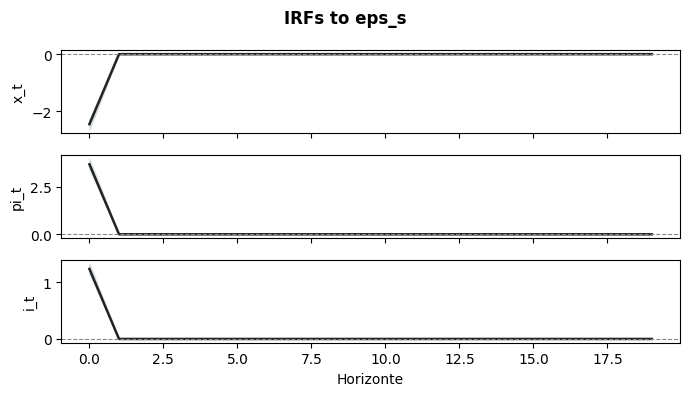

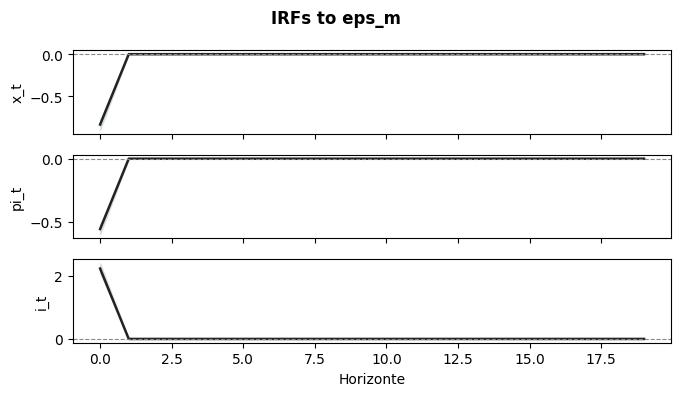

In [19]:
theta_mode = results["map"]["theta_map"]
irfs = model.impulse_responses(horizon=20, plot=True)

---

In [24]:
import numpy as np
from scipy.io import loadmat

mat = loadmat("nk_colombia/Output/nk_colombia_mode.mat", squeeze_me=True)

raw_names = [str(x).strip() for x in np.atleast_1d(mat["parameter_names"])]
mode_vals = np.atleast_1d(mat["xparam1"]).astype(float)

rename = {"eps_d": "sig_d", "eps_s": "sig_s", "eps_m": "sig_m"}
theta_dynare_mode_dict = {
    rename.get(name, name): val
    for name, val in zip(raw_names, mode_vals)}

theta_dyn = REG_NK_CO.from_econ_dict(theta_dynare_mode_dict)

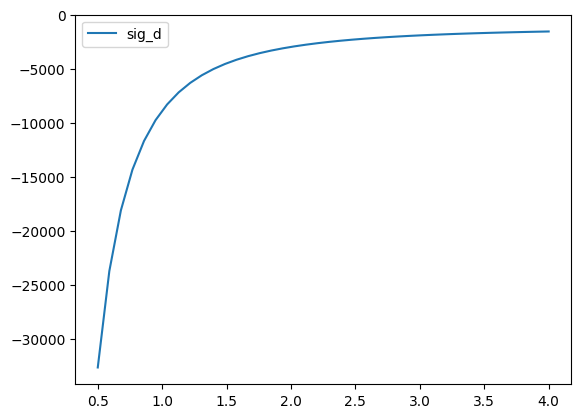

In [25]:
import matplotlib.pyplot as plt 
from src.inference.posteriors import *

def profile_param(param_name, grid):
    idx = REG_NK_CO.names.index(param_name)
    base = REG_NK_CO.from_econ_dict(theta_dynare_mode_dict)
    vals = []
    for val in grid:
        theta = base.copy()
        theta[idx] = REG_NK_CO.params[idx].inv(val)
        lp = log_posterior(
            theta, Y, model._equations, model._y_t, model._y_tp1,
            model._eps_t, REG_NK_CO,
            y_tm1=model._y_tm1, eta_t=model._eta_t,
            measurement=model._measurement, steady=model._steady_full,
            div=1 + 1e-6, include_jacobian=True,)
        vals.append(lp)
    return vals

grid_sig = np.linspace(0.5, 4.0, 40)
plt.plot(grid_sig, profile_param("sig_d", grid_sig), label="sig_d")
plt.legend(); plt.show()

In [26]:
from src.inference.posteriors import log_posterior

theta_dyn_work = REG_NK_CO.from_econ_dict(theta_dynare_mode_dict)
theta_our_mode = results["map"]["theta_map"]

log_kw = dict(
    y=Y,
    equations=model._equations,
    y_t=model._y_t,
    y_tp1=model._y_tp1,
    eps_t=model._eps_t,
    registry=REG_NK_CO,
    y_tm1=model._y_tm1,
    eta_t=model._eta_t,
    measurement=model._measurement,
    steady=model._steady_full,
    div=1.0 + 1e-6,
    include_jacobian=True,
)

lp_dyn = log_posterior(theta_dyn_work, **log_kw)
lp_our = log_posterior(theta_our_mode, **log_kw)

print("log posterior (Dynare mode):", lp_dyn)
print("log posterior (Our mode):   ", lp_our)
print("Difference our - dyn:", lp_our - lp_dyn)

log posterior (Dynare mode): -1760.660918640248
log posterior (Our mode):    -740.6083189464492
Difference our - dyn: 1020.0525996937987


In [27]:
from src.inference.likelihoods import log_like

theta_dyn_work = REG_NK_CO.from_econ_dict(theta_dynare_mode_dict)

common_args = dict(
    y=Y,
    equations=model._equations,
    y_t=model._y_t,
    y_tp1=model._y_tp1,
    eps_t=model._eps_t,
    registry=REG_NK_CO,
    y_tm1=model._y_tm1,
    eta_t=model._eta_t,
    measurement=model._measurement,
    steady=model._steady_full,
    div=1.0 + 1e-6,
)

log_prior_dyn = REG_NK_CO.log_prior(theta_dyn_work, include_jacobian=True)
log_like_dyn = log_like(theta_dyn_work, **common_args)

print("log prior (Dynare mode):      ", log_prior_dyn)
print("log likelihood (Dynare mode): ", log_like_dyn)
print("log post = prior + like:       ", log_prior_dyn + log_like_dyn)


log prior (Dynare mode):       -40.02253997146908
log likelihood (Dynare mode):  -1720.6383786687788
log post = prior + like:        -1760.660918640248


In [29]:
from scipy.io import loadmat
import numpy as np

mat_dyn = loadmat("Octave_implementation/colombia_nk_quarterly.mat", squeeze_me=True)
Y_dyn = np.column_stack([mat_dyn["x"], mat_dyn["pi"], mat_dyn["i"]]).astype(float)

def describe_matrix(label, arr):
    print(f"{label} → shape {arr.shape}")
    print("  mean:", np.mean(arr, axis=0))
    print("  std :", np.std(arr, axis=0))
    print()

describe_matrix("Python Y", Y)
describe_matrix("Dynare Y", Y_dyn)
print("Std ratio (python/dynare):", np.std(Y, axis=0) / np.std(Y_dyn, axis=0))



Python Y → shape (82, 3)
  mean: [-1.97500552e-11  4.79680563e+00  6.05452992e+00]
  std : [2.80398665 2.50072101 2.99293276]

Dynare Y → shape (82, 3)
  mean: [-1.97500552e-11  4.79680563e+00  6.05452992e+00]
  std : [2.80398665 2.50072101 2.99293276]

Std ratio (python/dynare): [1. 1. 1.]
